In [6]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8')
%matplotlib inline

df = pd.read_csv(r"C:\Users\User\Desktop\ppm_dummy_data.csv")

In [10]:
df.shape

(1000, 146)

In [8]:
df.head() #first 5 rows of data


,Account_Key,Billing_Num,Book_key,Book_Cycle,Billing_Cycle,Balance,BAR,Total_Due,TDtoBRatio,Instalment,...,HomeNumber3_TelType,HomeNumber3_LatestDate,Employer1_OriginalEmployerName,Employer1_Occupation,Employer1_LatestDate,Employer1_EmployerTelephone,Employer2_OriginalEmployerName,Employer2_Occupation,Employer2_LatestDate,Employer2_EmployerTelephone
0,1104955506,2,664,Nov 2025,1,54297.61,0.9245,50199.54,0.9245,1274.78,...,Cell,2020-09-06,NaN,Consultant,2024-07-24,719015621.0,Shoprite,Manager,2019-09-14,NaN
1,1104951152,4,6634,Oct 2025,2,40717.83,0.3927,15990.69,0.3927,1382.79,...,Cell,2024-05-14,Eskom,Manager,2023-08-02,810378947.0,Eskom,NaN,2019-11-21,NaN
2,1106011444,1,6637,Nov 2025,4,14947.46,0.4821,7206.31,0.4821,494.67,...,Home,2021-12-18,Self Employed,NaN,2021-07-25,NaN,Self Employed,NaN,NaN,NaN
3,1106019167,4,6647,Nov 2025,3,44162.96,0.9494,41927.03,0.9494,1657.20,...,NaN,NaN,Sasol,Driver,NaN,NaN,Self Employed,Director,NaN,NaN
4,1106014362,1,664,Nov 2025,2,26620.48,0.4033,10735.72,0.4033,1491.31,...,Work,2023-08-16,NaN,NaN,2019-12-17,765304032.0,XYZ Ltd,Technician,2021-07-05,NaN


In [11]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 146 entries, Account_Key to Employer2_EmployerTelephone
dtypes: float64(73), int64(34), object(8), str(31)
memory usage: 1.3+ MB


In [12]:
#printing columns by datatype
print("INT columns:", df.select_dtypes('int64').columns.tolist())
print("FLOAT columns:", df.select_dtypes('float64').columns.tolist())
print("STR/OBJ columns:", df.select_dtypes(['object','str']).columns.tolist())

INT columns: ['Account_Key', 'Billing_Num', 'Book_key', 'Billing_Cycle', 'Opening_acc_status', 'Opening_acc_age', 'Deliquency', 'DC', 'Recency', 'Account_Age', 'Case_Age', 'Original_Band', 'Current_Band', 'Existing_Account', 'Digigroup', 'Missing', 'PContacts', 'PRPCs', 'PSMSs', 'PEmails', 'PLetters', 'PDOs', 'PPTPs', 'PAttempts', 'Previous_Account', 'Previous_Payment', 'Previous_Cure', 'Current_Payment', 'Current_Cure', 'LSM', 'Income_Band', 'Home_Ownership_Status', 'Director_Status', 'Judgements1_JudgmentAmount']
FLOAT columns: ['Balance', 'BAR', 'Total_Due', 'TDtoBRatio', 'Instalment', 'Opening_Balance', 'Opening_Arrears', 'Opening_Total_Due', 'Current_Due', 'Xdays_Due', 'Due_30days', 'Due_60days', 'Due_90days', 'Due_120days', 'Due_150days', 'Due_180days', 'Due_210days', 'Current_per', 'Xdays_per', '30days_per', '60days_per', '90days_per', '120days_per', '150days_per', '180days_per', '210days_per', 'TDtoBal', 'ARtoBal', 'PropensistyToRol', 'BehaviourRiskScore', 'PaymentProjectionSco

In [20]:
# Calculate missing % per column
missing_perc = df.isnull().mean()  # gives value between 0 and 1

# Drop columns where missing > 70%
df_clean = df.loc[:, missing_perc <= 0.70]

# See what got dropped
dropped = df.columns[missing_perc > 0.70].tolist()
print(f"Dropped {len(dropped)} columns:")
print(dropped)

print(f"\nBefore: {df.shape}  →  After: {df_clean.shape}")

Dropped 6 columns:
['Deceased1_DateOfDeath', 'Deceased1_PlaceOfDeath', 'Address1_ComplexNumber', 'Judgements1_PersonName', 'Judgements1_Plaintiff', 'Judgements1_Attorneys']

Before: (1000, 146)  →  After: (1000, 140)


In [22]:
summary= pd.DataFrame({ 
    'dtype': df.dtypes,
    'nulls': df.isnull().sum(),
    'null_%': (df.isnull().mean() * 100).round(1),
    'unique': df.nunique(),
    'sample_val': df.iloc[0]  # first row as a sample

})
print(summary)

                                  dtype  nulls  null_%  unique   sample_val
Account_Key                       int64      0     0.0     993   1104955506
Billing_Num                       int64      0     0.0       4            2
Book_key                          int64      0     0.0       8          664
Book_Cycle                          str      0     0.0       4     Nov 2025
Billing_Cycle                     int64      0     0.0       4            1
...                                 ...    ...     ...     ...          ...
Employer1_EmployerTelephone     float64    480    48.0     520  719015621.0
Employer2_OriginalEmployerName      str    351    35.1      11     Shoprite
Employer2_Occupation                str    324    32.4      11      Manager
Employer2_LatestDate                str    353    35.3     595   2019-09-14
Employer2_EmployerTelephone     float64    496    49.6     504          NaN

[146 rows x 5 columns]


In [24]:
print(df.columns.tolist())


['Account_Key', 'Billing_Num', 'Book_key', 'Book_Cycle', 'Billing_Cycle', 'Balance', 'BAR', 'Total_Due', 'TDtoBRatio', 'Instalment', 'Opening_Balance', 'Opening_Arrears', 'Opening_Total_Due', 'Opening_acc_status', 'Opening_acc_age', 'Current_Due', 'Xdays_Due', 'Due_30days', 'Due_60days', 'Due_90days', 'Due_120days', 'Due_150days', 'Due_180days', 'Due_210days', 'Current_per', 'Xdays_per', '30days_per', '60days_per', '90days_per', '120days_per', '150days_per', '180days_per', '210days_per', 'Deliquency', 'DC', 'TDtoBal', 'ARtoBal', 'Recency', 'Account_Age', 'Case_Age', 'Original_Band', 'Current_Band', 'Existing_Account', 'PropensistyToRol', 'BehaviourRiskScore', 'PaymentProjectionScore', 'Digigroup', 'Contact_Score', 'Credit_Risk', 'Missing', 'PContacts', 'PRPCs', 'PSMSs', 'PEmails', 'PLetters', 'PDOs', 'PPTPs', 'PAttempts', 'Previous_Account', 'Previous_Total_Due', 'Previous_Payment', 'Previous_Payment_Amount', 'Previous_Payment_Perc', 'Previous_Cure', 'Current_Payment', 'Current_Payment

In [25]:
#target column is Current_Payment
# Check Current_Payment
print(df['Current_Payment'].value_counts())
print(df['Current_Payment'].dtype)
print(df['Current_Payment'].unique())


Current_Payment
0    741
1    259
Name: count, dtype: int64
int64
[1 0]


Note: An alternate target could be Current_Cure so let's check it.

In [28]:
# Check Current_Cure
print(df['Current_Cure'].value_counts())
print(df['Current_Cure'].dtype)
print(df['Current_Cure'].unique())

Current_Cure
0    1000
Name: count, dtype: int64
int64
[0]


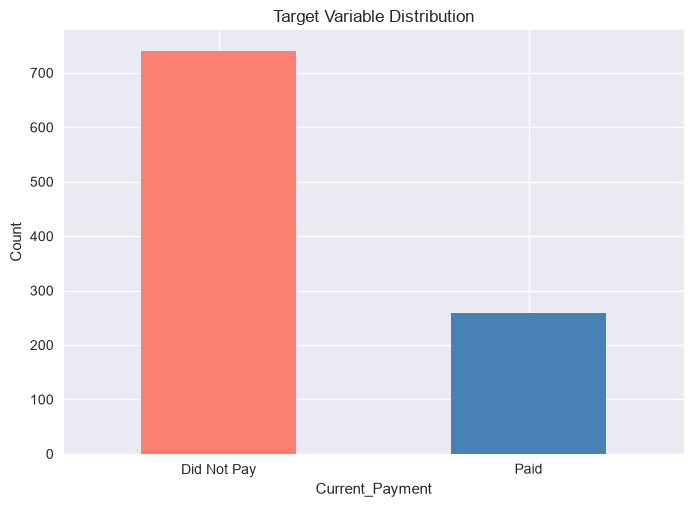

Current_Payment
0    74.1
1    25.9
Name: proportion, dtype: float64


In [29]:
#plotting current payment
df['Current_Payment'].value_counts().plot(kind='bar', color=['salmon', 'steelblue'])
plt.title('Target Variable Distribution')
plt.ylabel('Count')
plt.xticks([0, 1], ['Did Not Pay', 'Paid'], rotation=0)
plt.show()

print(df['Current_Payment'].value_counts(normalize=True) * 100)

In [30]:
TARGET = 'Current_Payment'

# Account / financial features
financial_cols = ['Balance', 'BAR', 'Total_Due', 'TDtoBRatio', 
                  'Instalment', 'Opening_Balance', 'Opening_Arrears']

# Delinquency / aging buckets
delinquency_cols = ['Current_Due', 'Xdays_Due', 'Due_30days', 'Due_60days',
                    'Due_90days', 'Due_120days', 'Due_150days', 
                    'Due_180days', 'Due_210days', 'Deliquency']

# Behaviour / scores
score_cols = ['PropensistyToRol', 'BehaviourRiskScore', 
              'PaymentProjectionScore', 'Contact_Score', 
              'Credit_Risk', 'Person1_Score', 'CreditScore1_CreditScore']

# Previous payment history
history_cols = ['Previous_Payment', 'Previous_Payment_Amount',
                'Previous_Payment_Perc', 'Previous_Cure']

# Demographics
demo_cols = ['Age', 'Gender', 'LSM', 'Income_Band', 
             'Home_Ownership_Status', 'Director_Status']

In [31]:
# How does pay rate vary by delinquency level?
print(df_clean.groupby('Deliquency')[TARGET].mean().sort_values(ascending=False))

# Pay rate by income band
print(df_clean.groupby('Income_Band')[TARGET].mean().sort_values(ascending=False))

# Pay rate by credit risk
print(df_clean.groupby('Credit_Risk')[TARGET].mean().sort_values(ascending=False))

Deliquency
3    0.410256
5    0.402439
6    0.383562
8    0.363636
2    0.363636
7    0.288889
9    0.275862
4    0.244444
1    0.124390
Name: Current_Payment, dtype: float64
Income_Band
3     0.283333
99    0.281690
5     0.278846
1     0.262500
7     0.255102
2     0.250000
6     0.227848
8     0.220779
4     0.185714
Name: Current_Payment, dtype: float64
Credit_Risk
 1.0     0.328947
 8.0     0.327869
 9.0     0.313953
 3.0     0.274194
 6.0     0.272727
 7.0     0.268657
 0.0     0.253521
 4.0     0.252525
-1.0     0.243243
 5.0     0.222222
 2.0     0.214286
 10.0    0.179487
Name: Current_Payment, dtype: float64


In [34]:
print(df_clean['Deliquency'].describe())

count    1000.000000
mean        3.183000
std         2.434222
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max         9.000000
Name: Deliquency, dtype: float64


In [36]:
from scipy.stats import pointbiserialr

score_cols = ['PropensistyToRol', 'BehaviourRiskScore', 
              'PaymentProjectionScore', 'Contact_Score', 
              'CreditScore1_CreditScore']

results = []

for col in score_cols:
    # drop rows where either column is null
    temp = df_clean[[col, TARGET]].dropna()
    
    corr, pval = pointbiserialr(temp[TARGET], temp[col])
    results.append({
        'Feature': col,
        'Correlation': round(corr, 3),
        'P_Value': round(pval, 4),
        'Significant': 'YES ✅' if pval < 0.05 else 'NO ❌'
    })

results_df = pd.DataFrame(results).sort_values('Correlation', ascending=False)
print(results_df.to_string(index=False))

                 Feature  Correlation  P_Value Significant
      BehaviourRiskScore        0.030   0.3670        NO ❌
CreditScore1_CreditScore        0.025   0.4753        NO ❌
        PropensistyToRol        0.018   0.5785        NO ❌
           Contact_Score        0.016   0.6261        NO ❌
  PaymentProjectionScore       -0.028   0.3962        NO ❌


In [37]:
# 1. What is Current_Payment actually?
print(df_clean['Current_Payment'].value_counts())
print(df_clean['Current_Payment'].dtype)

Current_Payment
0    741
1    259
Name: count, dtype: int64
int64


In [38]:
# 2. See all candidate columns side by side
print(df_clean[['Current_Payment', 
                'Current_Payment_Amount',
                'Current_Cure',
                'Previous_Payment',
                'Previous_Cure']].head(20))

    Current_Payment  Current_Payment_Amount  Current_Cure  Previous_Payment  \
0                 1                30819.96             0                 0   
1                 0                    0.00             0                 1   
2                 1                 6043.74             0                 0   
3                 1                31228.10             0                 1   
4                 0                    0.00             0                 0   
5                 0                    0.00             0                 0   
6                 0                    0.00             0                 0   
7                 0                    0.00             0                 1   
8                 0                    0.00             0                 0   
9                 1                14415.83             0                 1   
10                0                    0.00             0                 0   
11                0                    0.00         

In [39]:
# 3. Check each one for binary structure
for candidate in ['Current_Cure', 'Previous_Payment', 'Previous_Cure']:
    print(f"\n--- {candidate} ---")
    print(df_clean[candidate].value_counts())


--- Current_Cure ---
Current_Cure
0    1000
Name: count, dtype: int64

--- Previous_Payment ---
Previous_Payment
0    742
1    258
Name: count, dtype: int64

--- Previous_Cure ---
Previous_Cure
0    1000
Name: count, dtype: int64


In [40]:
#removing null columns
df_clean.drop(columns=['Current_Cure', 'Previous_Cure'], inplace=True)

In [41]:
from scipy.stats import pointbiserialr

# Get all numeric columns except target
num_cols = df_clean.select_dtypes(include='number').columns.tolist()
num_cols.remove('Current_Payment')

# Run point biserial on each
results = []
for col in num_cols:
    temp = df_clean[[col, 'Current_Payment']].dropna()
    if temp[col].nunique() <= 1:
        continue
    corr, pval = pointbiserialr(temp['Current_Payment'], temp[col])
    results.append([col, round(corr, 3), round(pval, 4)])

# Show results — strongest first
results_df = pd.DataFrame(results, columns=['Feature', 'Correlation', 'P_Value'])
results_df = results_df.reindex(results_df['Correlation'].abs().sort_values(ascending=False).index)
print(results_df.to_string(index=False))

                    Feature  Correlation  P_Value
     Current_Payment_Amount        0.778   0.0000
                    Recency       -0.339   0.0000
                Current_per       -0.241   0.0000
         Previous_Total_Due        0.211   0.0000
                  PAttempts        0.200   0.0000
                      PSMSs        0.193   0.0000
                  Xdays_per        0.191   0.0000
                  PContacts        0.182   0.0000
                Account_Age        0.175   0.0000
                 Deliquency        0.175   0.0000
                   Case_Age        0.175   0.0000
                         DC        0.175   0.0000
                Current_Due       -0.172   0.0000
                 30days_per        0.167   0.0000
                  Xdays_Due        0.148   0.0000
                      PRPCs        0.140   0.0000
                 90days_per        0.138   0.0000
      Previous_Payment_Perc        0.131   0.0000
                 Due_90days        0.131   0.0000


In [ ]:
#these are the relevant columns: the ones with correlation above 0.1 or below -0.1

In [42]:
#correlation of 0.778 is too high, 'Current_Payment' is leaking data thus we remove it
df_clean.drop(columns=['Current_Payment_Amount'], inplace=True)

In [43]:
#after identifying strong features, we remove the other unnecesary ones
strong_features = [
    'Recency', 'Current_per', 'Previous_Total_Due', 'PAttempts',
    'PSMSs', 'Xdays_per', 'PContacts', 'Account_Age', 'Deliquency',
    'Case_Age', 'DC', 'Current_Due', '30days_per', 'Xdays_Due',
    'PRPCs', '90days_per', 'Previous_Payment_Perc', 'Due_90days',
    'Previous_Payment', 'Previous_Payment_Amount', 'Due_30days',
    'Due_120days', 'Existing_Account', '120days_per'
]
cols_to_keep = strong_features + ['Current_Payment']

df_model = df_clean[cols_to_keep]

print(f"Before: {df_clean.shape}")
print(f"After:  {df_model.shape}")

Before: (1000, 137)
After:  (1000, 25)


In [44]:
#removing missing columns
missing = pd.DataFrame({
    'missing_count': df_model.isnull().sum(),
    'missing_pct': (df_model.isnull().mean() * 100).round(1)
}).sort_values('missing_pct', ascending=False)

# Only show columns that actually have missing values
print(missing[missing['missing_count'] > 0])

#fill missing with median(more accurate than mean values)
num_cols = df_model.select_dtypes(include='number').columns.tolist()
num_cols.remove('Current_Payment')  # don't fill target

df_model[num_cols] = df_model[num_cols].fillna(df_model[num_cols].median())



Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []


In [45]:
print(df_model.isnull().sum().sum())  # should print 0


0


In [ ]:
#Removed missing values initially and thus there are none left

In [46]:
#Checking for outliers

df_model[num_cols].describe()


,Recency,Current_per,Previous_Total_Due,PAttempts,PSMSs,Xdays_per,PContacts,Account_Age,Deliquency,Case_Age,...,PRPCs,90days_per,Previous_Payment_Perc,Due_90days,Previous_Payment,Previous_Payment_Amount,Due_30days,Due_120days,Existing_Account,120days_per
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2487.139000,0.565765,19219.482700,10.990000,1.912000,0.156397,3.727000,46.880000,3.183000,1420.681000,...,1.928000,0.045996,0.193272,1197.849130,0.258000,4857.299690,2589.207430,733.048700,0.389000,0.029109
std,4304.454271,0.392974,18365.390892,9.980657,1.865405,0.196930,3.432529,40.475052,2.434222,1213.903535,...,2.432845,0.087121,0.335719,2898.423317,0.437753,10834.541201,4661.955166,2190.733238,0.776068,0.069300
min,0.000000,0.000400,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000
25%,13.000000,0.189000,538.500000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,44.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.465300,15835.425000,9.000000,2.000000,0.075150,3.000000,42.000000,2.000000,1270.500000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,76.000000,1.000000,31219.942500,19.250000,4.000000,0.248525,7.000000,84.000000,5.000000,2520.250000,...,3.000000,0.046100,0.519800,488.170000,1.000000,1252.725000,3381.535000,0.000000,1.000000,0.000000
max,9999.000000,1.000000,80513.040000,30.000000,5.000000,0.974400,10.000000,120.000000,9.000000,3621.000000,...,10.000000,0.455900,0.995400,25665.010000,1.000000,66658.740000,41928.540000,20048.650000,1.000000,0.387200


In [47]:
#removing 9999s
# Replace 9999 with NaN across entire dataframe
df_model = df_model.replace(9999, np.nan)

# Fill NaN with median for each column
num_cols = df_model.select_dtypes(include='number').columns.tolist()
num_cols.remove('Current_Payment')

df_model[num_cols] = df_model[num_cols].fillna(df_model[num_cols].median())

# Confirm no more 9999s or nulls
print("9999s remaining:", (df_model == 9999).sum().sum())
print("Nulls remaining:", df_model.isnull().sum().sum())

9999s remaining: 0
Nulls remaining: 0


In [ ]:
#Existing_Account min = -1.0 — Same issue as Credit_Risk earlier

print(df_model['Existing_Account'].value_counts())

# Replace -1 with NaN then fill with median
df_model['Existing_Account'] = df_model['Existing_Account'].replace(-1, np.nan)
df_model['Existing_Account'] = df_model['Existing_Account'].fillna(df_model['Existing_Account'].median())

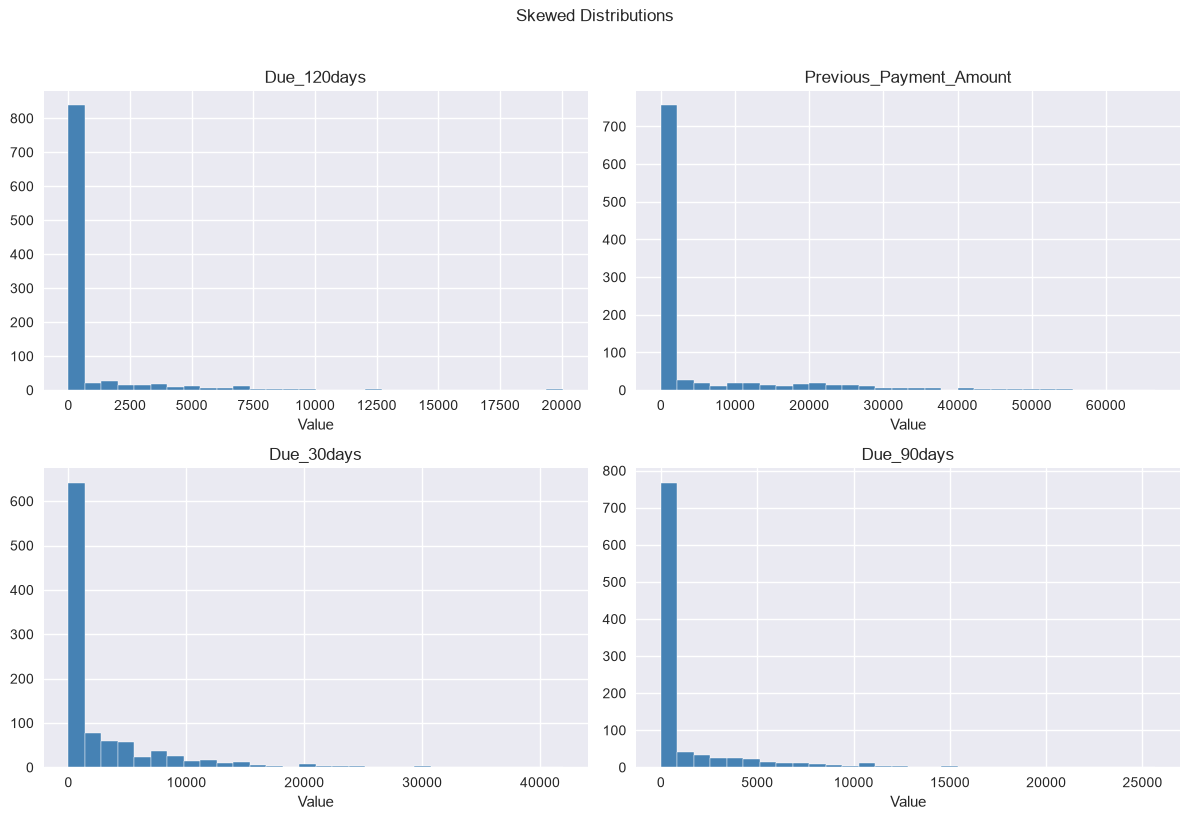

In [49]:
#Columns: 120,90,30 due days and Previous_Payment_Amount as heavily right-skewed by outliers
# Visualise the skew
skewed_cols = ['Due_120days', 'Previous_Payment_Amount', 'Due_30days', 'Due_90days']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(skewed_cols):
    axes[i].hist(df_model[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('Value')

plt.suptitle('Skewed Distributions', y=1.02)
plt.tight_layout()
plt.show()

In [50]:
#we need to balance it
# Log transform skewed columns (add 1 to handle zeros)
for col in skewed_cols:
    df_model[col + '_log'] = np.log1p(df_model[col])

# Drop originals
df_model.drop(columns=skewed_cols, inplace=True)

print(df_model.shape)

(1000, 25)


In [51]:
print(df_model.describe().T[['min', 'max', 'mean', 'std']])

                                min           max          mean           std
Recency                      0.0000     80.000000     22.326000     14.104988
Current_per                  0.0004      1.000000      0.565765      0.392974
Previous_Total_Due           0.0000  80513.040000  19219.482700  18365.390892
PAttempts                    0.0000     30.000000     10.990000      9.980657
PSMSs                        0.0000      5.000000      1.912000      1.865405
Xdays_per                    0.0000      0.974400      0.156397      0.196930
PContacts                    0.0000     10.000000      3.727000      3.432529
Account_Age                  0.0000    120.000000     46.880000     40.475052
Deliquency                   1.0000      9.000000      3.183000      2.434222
Case_Age                     0.0000   3621.000000   1420.681000   1213.903535
DC                           1.0000      9.000000      3.183000      2.434222
Current_Due                  1.2000  72278.180000  14954.214890 